# Dimensionality Reduction – Heart Disease Dataset
*PCA, t-SNE, UMAP - Risk Prediction project*  

---

## Table of Contents


<a id='imports'></a>
## Reproducibility & Imports  


In [1]:
# Reproducibility
import os, sys, umap, numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Imports
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

# Tools
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scripts.dimred.plots import plot_cumulative_variance, plot_3d
from scripts.dimred.pipeline import build_dimred_preprocessing_pipeline

SEED = 42

In [2]:
df_clean = pd.read_csv('../data/df_clean.csv')
df_clean.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0


In [3]:
# drop target 
df_copy = df_clean.copy()
TARGET_COL = 'num'

X_clean = df_copy.drop(columns=[TARGET_COL])
y = df_copy[TARGET_COL].astype(int)     # multiclass
y_bin = (y > 0).astype(int)             # binary

### Dimensionality Reduction Preprocessing Pipeline

The preprocessing pipeline prepares the dataset for dimensionality reduction by converting all features into a fully numeric, standardized format while excluding the target variable `num`. This ensures that only input features influence the structure of the lower-dimensional representation.

1. **Fixed Label Mappings**  
   - `sex`: Female → 0, Male → 1  
   - `fbs`: False → 0, True → 1, Missing → 2  
   - `exang`: False → 0, True → 1, Missing → 2  
   These mappings ensure consistent numeric representation for binary and ternary categorical features.

2. **Label Encoding of Nominal Variables**  
   - `dataset`, `cp`, `restecg`, `slope`  
   Each categorical value is replaced with an integer code (e.g., 0, 1, 2…) based on sorted unique values.  
   This approach avoids the dimensional expansion of one-hot encoding while preserving category identity.

3. **Z-Score Scaling (Standardization)**  
   - Applied to all numeric columns, including both originally continuous features and newly encoded categorical ones.  
   - Formula: \( z = \frac{x - \mu}{\sigma} \)  
   Standardization ensures that all variables contribute equally to the distance-based algorithms used in PCA, UMAP, and t-SNE.

4. **Target Variable**  
   - `num` is excluded from preprocessing and dimensionality reduction steps.  
   - It is retained separately for labeling, evaluation, or visualization (e.g., coloring clusters by class).


In [4]:
dimred_prep = build_dimred_preprocessing_pipeline()
X = dimred_prep.fit_transform(X_clean)
X.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope
0,1.007386,1,0,3,0.755639,-0.215021,1,1,0.474017,0,1.325576,1
1,1.432034,1,0,0,1.621952,0.790195,0,1,-1.153349,1,0.549855,2
2,1.432034,1,0,0,-0.688217,-0.290886,0,1,-0.339666,1,1.616471,2
3,-1.752828,1,0,2,-0.110675,0.107407,0,2,1.907648,0,2.489156,1
4,-1.328180,0,0,1,-0.110675,-0.765044,0,1,1.326446,0,0.452890,3


### Top features
Based on the results from feature analysys, top features, have been selected.

In [5]:
features_subset = ['oldpeak', 'age', 'thalch', 'cp', 'chol', 'trestbps', 'exang', 'restecg']
X = X[features_subset]

## PCA

In [6]:
# standarize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Explained variance ratio: [0.26289374 0.14531093 0.12565475 0.1197047  0.10533953 0.09724678
 0.0757332  0.06811638]
Total variance retained: 1.0000000000000002


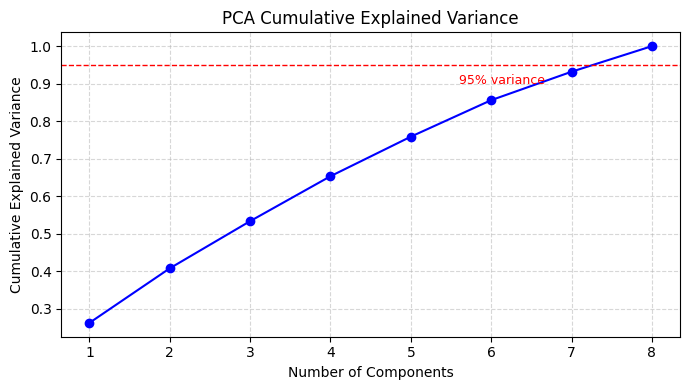

In [7]:
# PCA with all components
pca_full = PCA()
pca_full.fit(X_scaled)

# explained variance
explained_variance = pca_full.explained_variance_ratio_
print("Explained variance ratio:", explained_variance)
print("Total variance retained:", np.sum(explained_variance))
plot_cumulative_variance(explained_variance, show_target=0.95)


- The first component explains ~26% of the total variance.
- The first three components together explain ~53% of the variance.
- Around 7 to 8 components are needed to reach 95% variance.

In [8]:
X_pca = pca_full.transform(X_scaled)   # shape (n_samples, n_features)
X_3d = X_pca[:, :3]                    # first 3 principal components

explained_variance = np.round(pca_full.explained_variance_ratio_, 3)
print("Explained variance ratio:", explained_variance)
print("Total variance retained by 3 PCs:", round(explained_variance[:3].sum(), 3))

Explained variance ratio: [0.263 0.145 0.126 0.12  0.105 0.097 0.076 0.068]
Total variance retained by 3 PCs: 0.534


### Binary


[Binary] Variance kept by first 3 PCs: 0.534


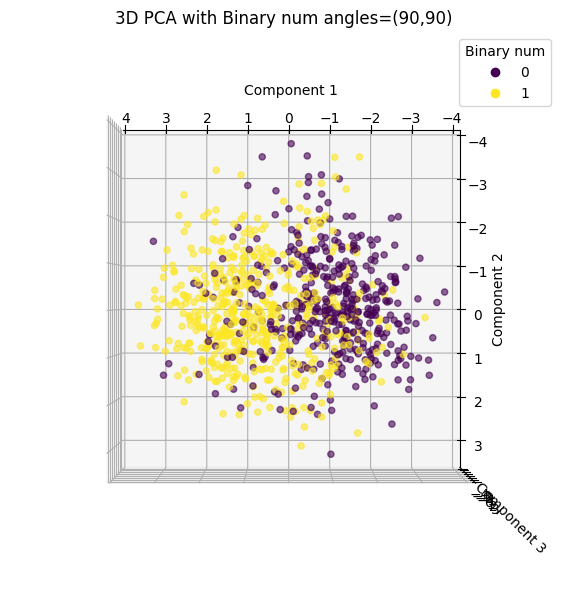

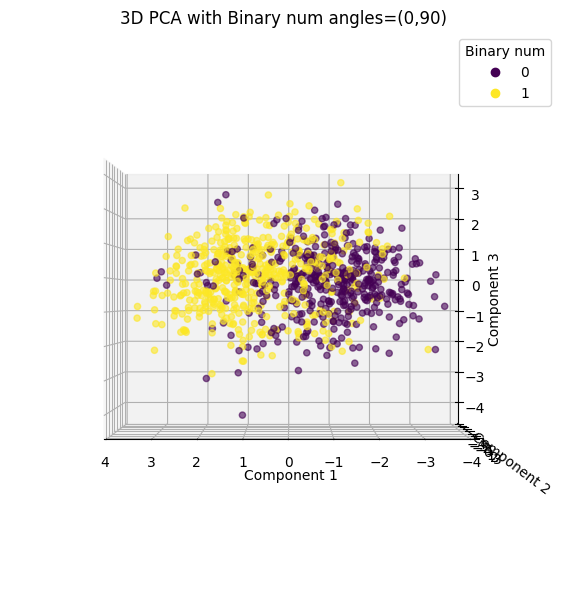

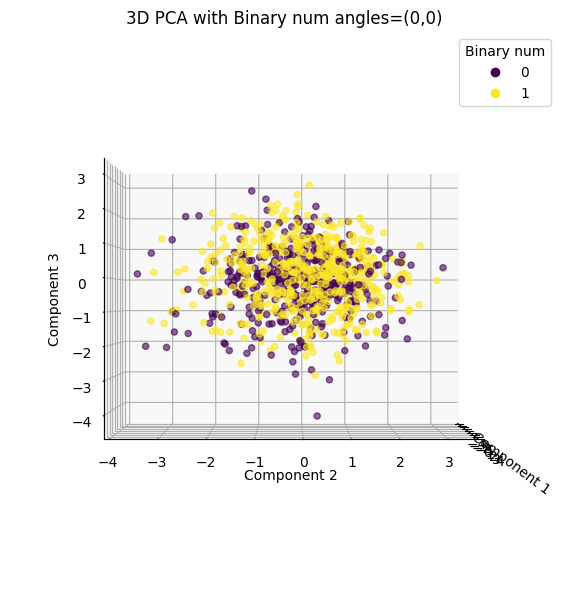

In [9]:
print("\n[Binary] Variance kept by first 3 PCs:", round(explained_variance[:3].sum(), 3))
plot_3d(X_3d, y_bin, algorithm="PCA", target_name="Binary num")

### Multiclass


[Multiclass] Variance kept by first 3 PCs: 0.534


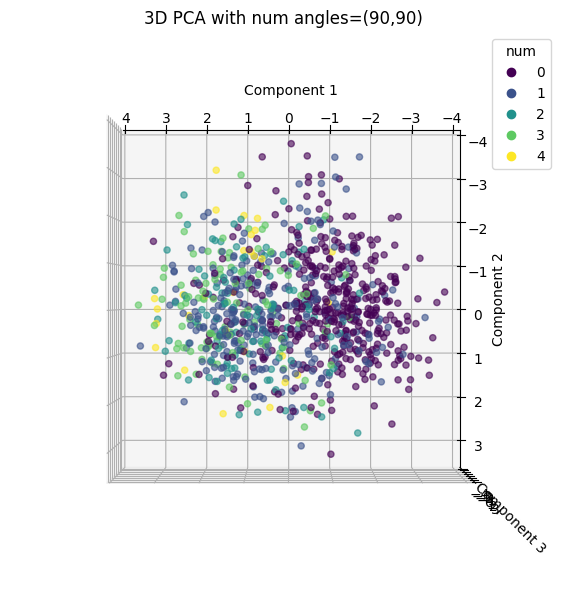

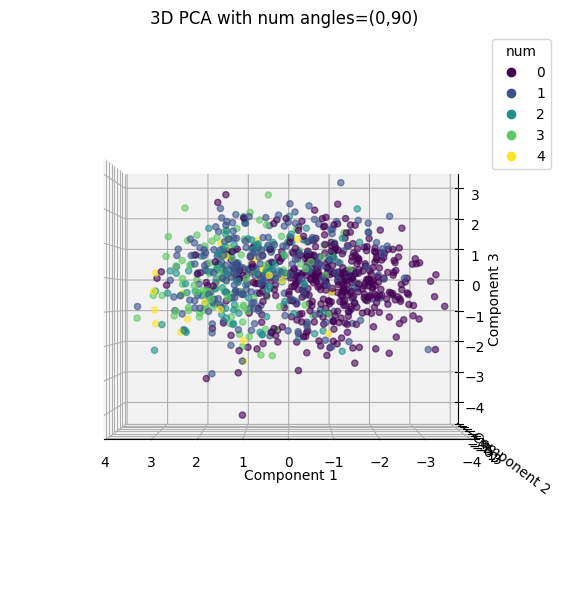

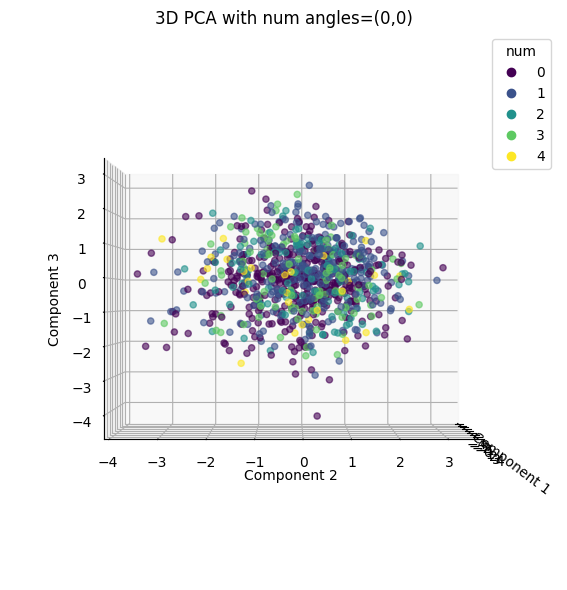

In [10]:
print("\n[Multiclass] Variance kept by first 3 PCs:", round(explained_variance[:3].sum(), 3))
plot_3d(X_3d, y, algorithm="PCA", target_name=TARGET_COL)

## t-SNE

In [11]:
tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    max_iter=1200,
    early_exaggeration=12.0,
    metric="cosine",
    init="pca",
    n_jobs=-1,
    angle=0.5,
    method="barnes_hut"
)
embedding_tsne = tsne.fit_transform(X)

### Binary

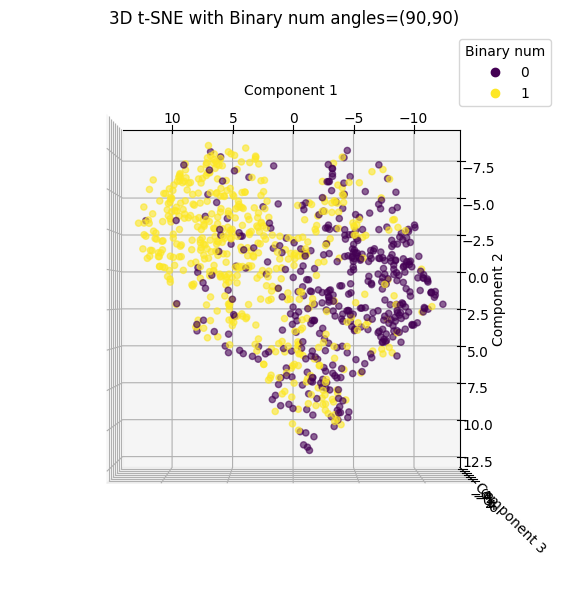

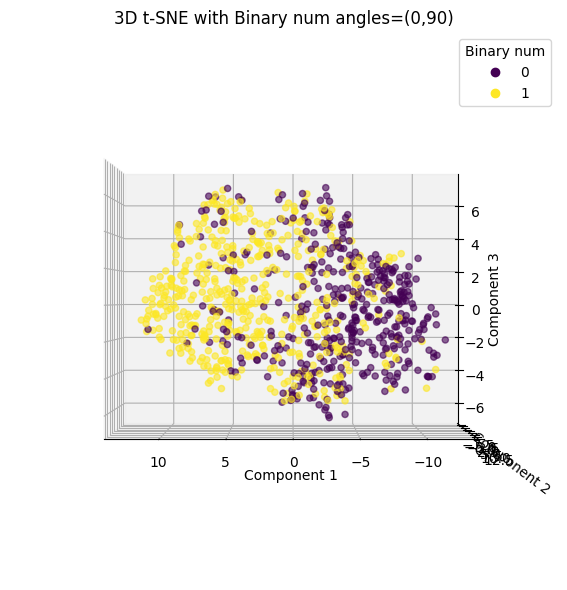

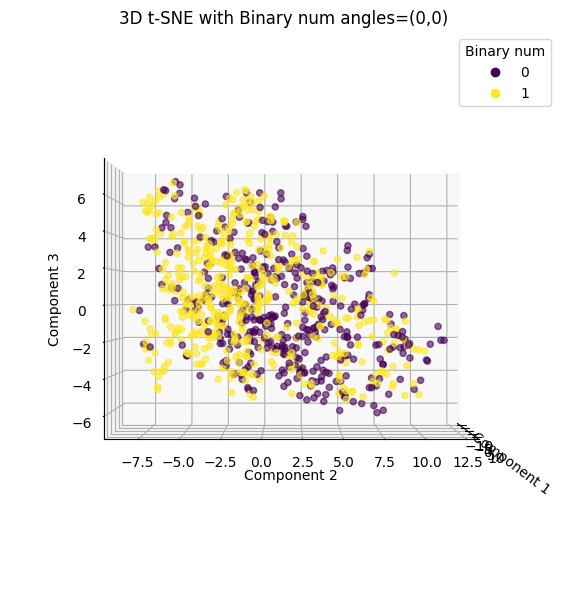

In [12]:
plot_3d(embedding_tsne, y_bin, algorithm="t-SNE", target_name="Binary num")

### Multiclass

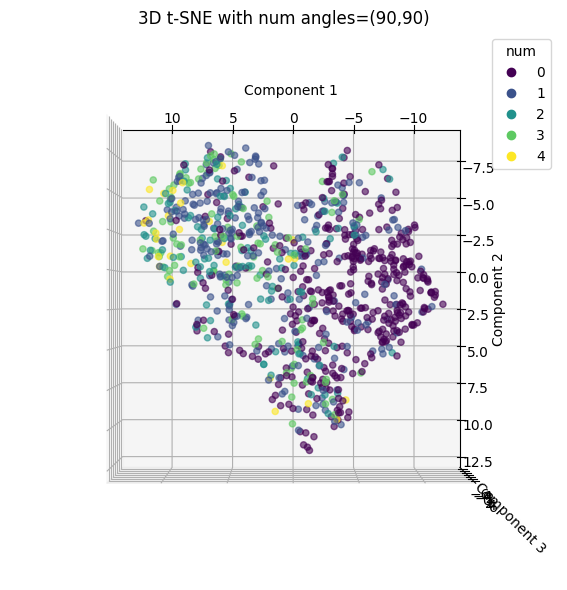

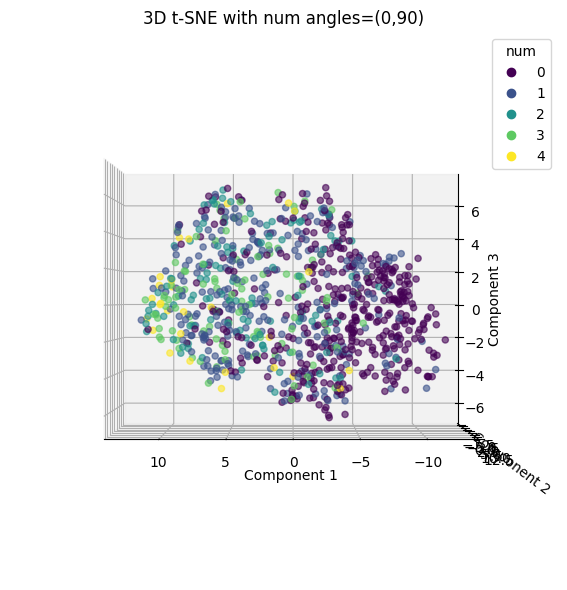

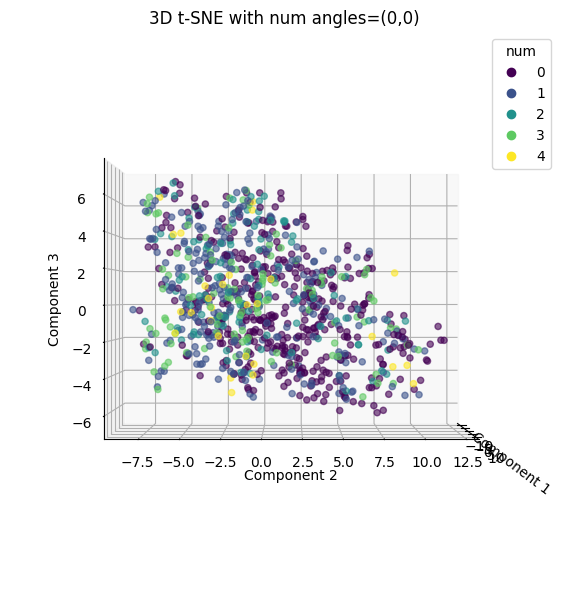

In [13]:
plot_3d(embedding_tsne, y, algorithm="t-SNE", target_name=TARGET_COL)

## UMAP

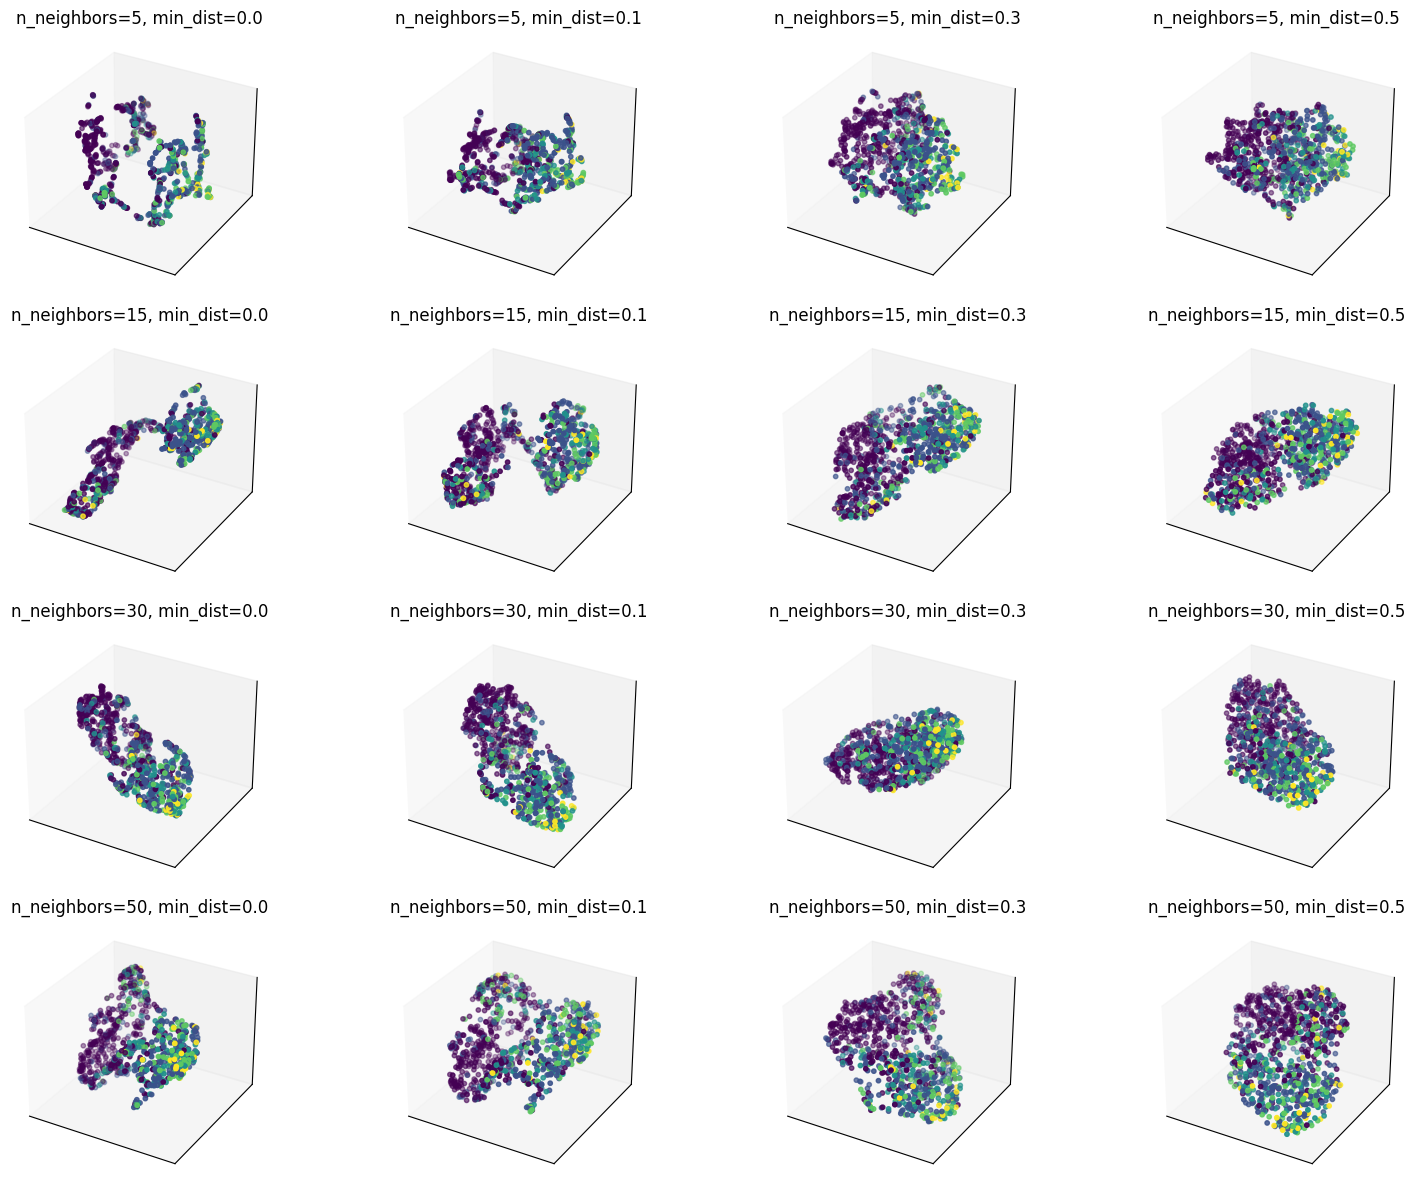

In [14]:
# best parmemters finder 
n_neighbors_values = [5, 15, 30, 50]
min_dist_values = [0.0, 0.1, 0.3, 0.5]
metrics = ["euclidean", "cosine"]

fig, axes = plt.subplots(
    len(n_neighbors_values), len(min_dist_values), figsize=(16, 12),
    subplot_kw={"projection": "3d"}
)

for i, n_neighbors in enumerate(n_neighbors_values):
    for j, min_dist in enumerate(min_dist_values):
        reducer = umap.UMAP(
            n_components=3,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric="cosine",   # or try euclidean
            n_jobs=-1
        )
        embedding = reducer.fit_transform(X)

        ax = axes[i, j]
        sc = ax.scatter(embedding[:,0], embedding[:,1], embedding[:,2],
                        c=y, cmap="viridis", s=10)
        ax.set_title(f"n_neighbors={n_neighbors}, min_dist={min_dist}")
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

plt.tight_layout()
plt.show()


In [15]:
# UMAP reducer
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=15,      # controls local/global structure balance
    min_dist=0.05,       # controls cluster compactness
    metric="cosine",
    n_jobs=-1
)

# Fit and transform
embedding = reducer.fit_transform(X)

### Binary

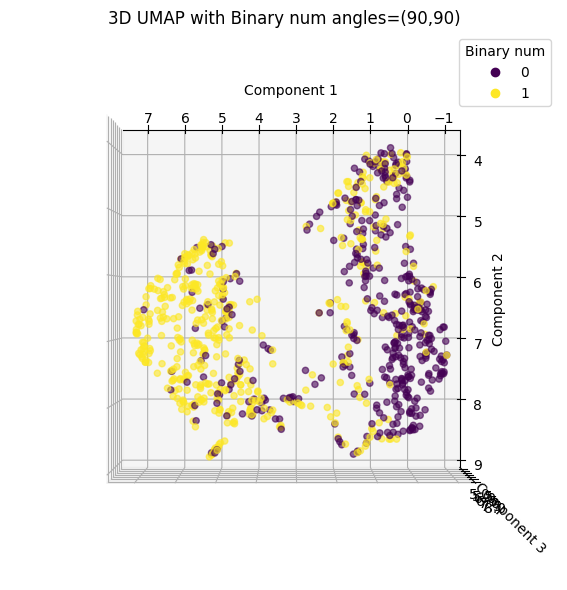

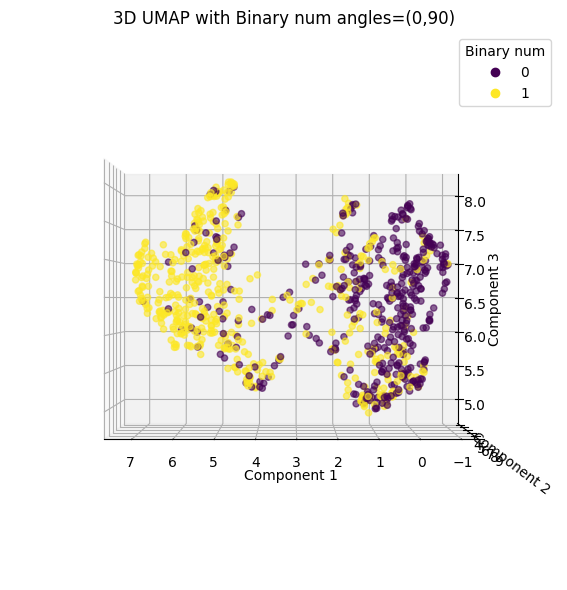

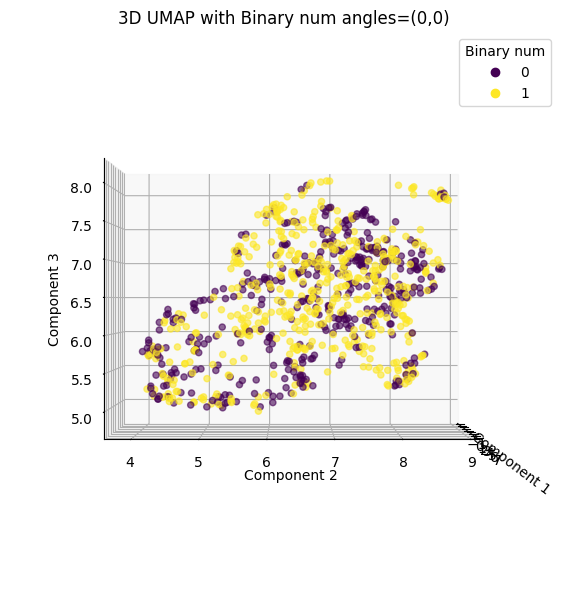

In [16]:
plot_3d(embedding, y_bin, algorithm="UMAP", target_name="Binary num")

### Multiclass

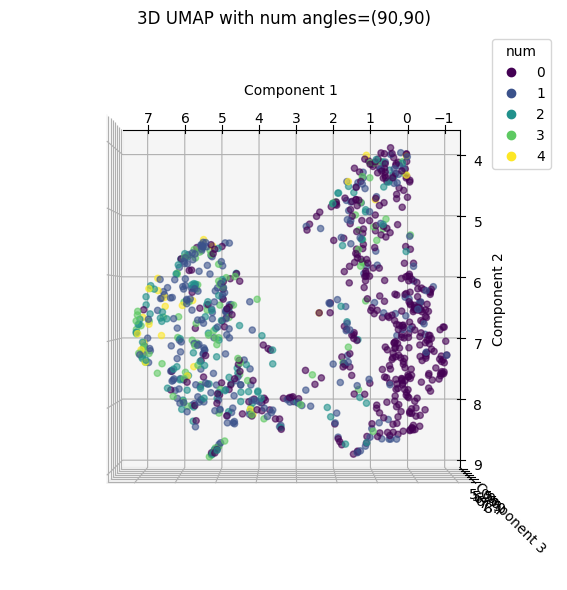

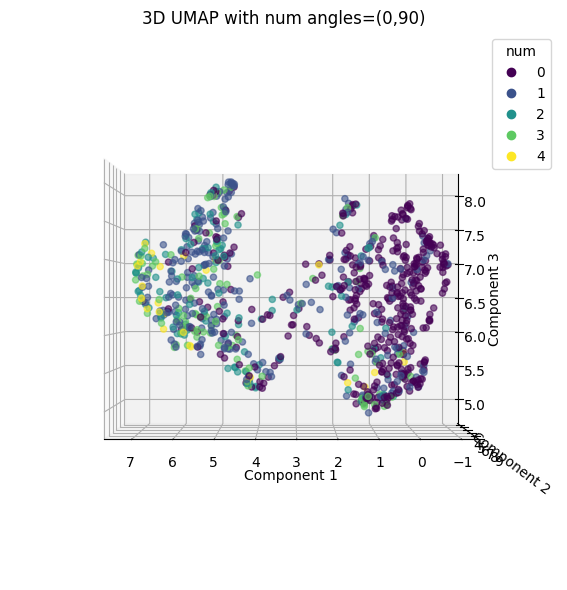

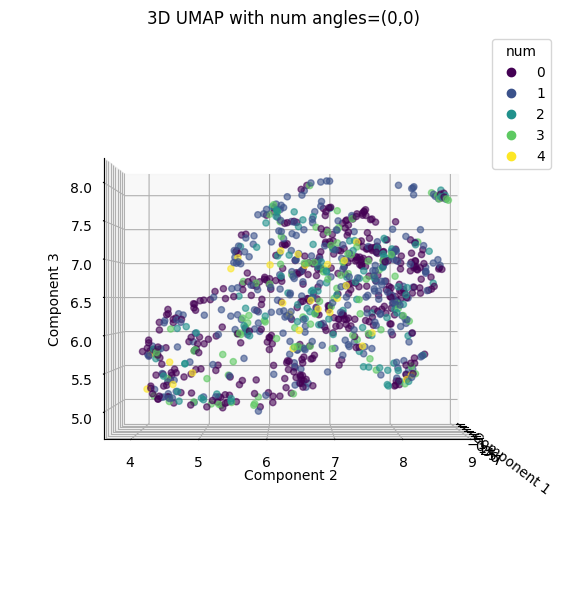

In [17]:
plot_3d(embedding, y, algorithm="UMAP", target_name=TARGET_COL)